In [5]:

import pandas as pd
df = pd.read_csv("/content/cleaned_data.csv")
df.head()

,Account_length,Area_code,International_plan,Voice_mail_plan,Number_vmail_messages,Total_day_minutes,Total_day_calls,Total_day_charge,Total_eve_minutes,Total_eve_calls,Total_eve_charge,Total_night_minutes,Total_night_calls,Total_night_charge,Total_intl_minutes,Total_intl_calls,Total_intl_charge,Customer_service_calls,Churn
0,128,415,0,1,25,265.1,110,45.05,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,1
4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [7]:
#REGRESSION
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("/content/cleaned_data.csv")

# Predict "Total day minutes" (continuous)
X = df.drop("Total_day_minutes", axis=1)
y = df["Total_day_minutes"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
print("Sample Prediction:", model.predict(X_test[:5]))

Sample Prediction: [263.07660057 276.66242843]


In [10]:
#WEB SCRAPING
import pandas as pd

# Load dataset
df = pd.read_csv("/content/churn-bigml-80.csv")

# Simulate "scraping" by selecting useful columns
data = df[["State", "Account length", "Area code", "Churn"]]

# Save as scraped data
data.to_csv("scraped_data.csv", index=False)

data.head()

,State,Account length,Area code,Churn
0,KS,128,415,False
1,OH,107,415,False
2,NJ,137,415,False
3,OH,84,408,False
4,OK,75,415,False


In [11]:
#DATA PREPROCESSING
import pandas as pd

df = pd.read_csv("/content/churn-bigml-80.csv")

# Handle missing values
df = df.fillna(df.mean(numeric_only=True))

# Remove duplicates
df = df.drop_duplicates()

# Convert categorical to numeric
df = pd.get_dummies(df)

# Save cleaned data
df.to_csv("cleaned_data.csv", index=False)

df.head()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,...,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,International plan_No,International plan_Yes,Voice mail plan_No,Voice mail plan_Yes
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,...,False,False,False,False,False,False,True,False,False,True
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,...,False,False,False,False,False,False,True,False,False,True
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,...,False,False,False,False,False,False,True,False,True,False
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,...,False,False,False,False,False,False,False,True,True,False
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,...,False,False,False,False,False,False,False,True,True,False


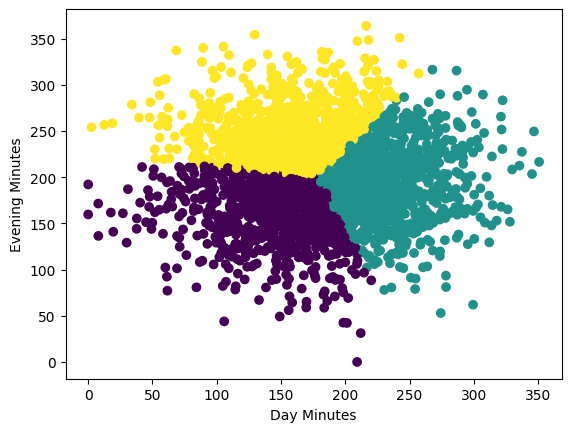

In [16]:
#CLUSTERING
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("/content/cleaned_data.csv")

# Select numeric features
X = df[["Total day minutes", "Total eve minutes"]]

# KMeans
kmeans = KMeans(n_clusters=3)
df["Cluster"] = kmeans.fit_predict(X)

# Plot
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=df["Cluster"])
plt.xlabel("Day Minutes")
plt.ylabel("Evening Minutes")
plt.show()

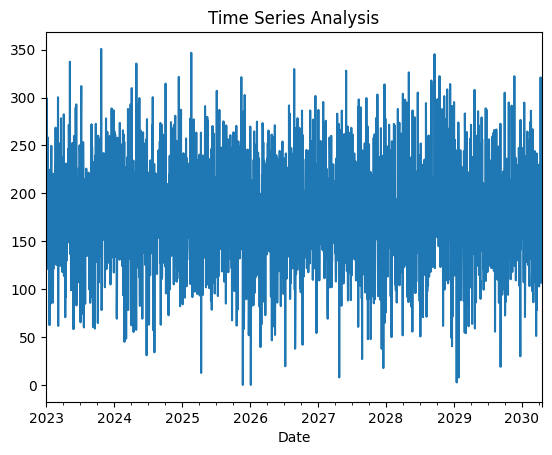

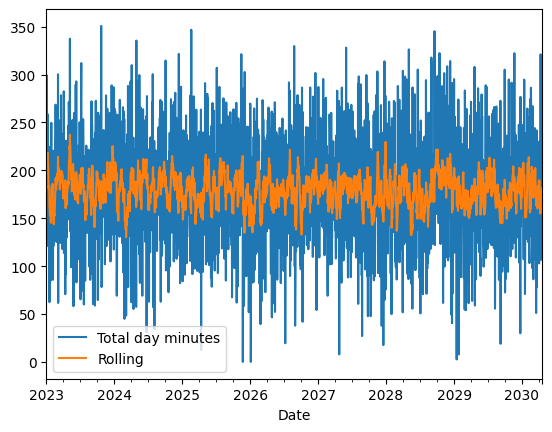

In [17]:
#TIME SERIES
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/churn-bigml-80.csv")

# Create time index
df["Date"] = pd.date_range(start="2023-01-01", periods=len(df))
df.set_index("Date", inplace=True)

# Use numeric column
df["Total day minutes"].plot()
plt.title("Time Series Analysis")
plt.show()

# Rolling average
df["Rolling"] = df["Total day minutes"].rolling(10).mean()
df[["Total day minutes", "Rolling"]].plot()
plt.show()

In [23]:
#NPL
# ==============================
# STEP 1: Import Libraries
# ==============================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# ==============================
# STEP 2: Upload File
# ==============================
from google.colab import files
uploaded = files.upload()

# ==============================
# STEP 3: Load Dataset (AUTO)
# ==============================
file_name = list(uploaded.keys())[0]
df = pd.read_csv("/content/3) Sentiment dataset.csv")

print("Dataset Preview:")
print(df.head())
print("\nColumns:", df.columns)

# ==============================
# STEP 4: Select Columns (AUTO)
# ==============================
# First column = text, second = label
X = df.iloc[:, 0].astype(str)
y = df.iloc[:, 1]

# Handle missing text
X = X.fillna("")

# ==============================
# STEP 5: Convert Text → Numeric
# ==============================
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X)

# ==============================
# STEP 6: Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# STEP 7: Train Model
# ==============================
model = MultinomialNB()
model.fit(X_train, y_train)

# ==============================
# STEP 8: Evaluate
# ==============================
accuracy = model.score(X_test, y_test)
print("\nAccuracy:", accuracy)

# Detailed report
y_pred = model.predict(X_test)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Saving 3) Sentiment dataset.csv to 3) Sentiment dataset (2).csv
Dataset Preview:
   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        I

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_